IMPORTING LIBBRARIES

In [9]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

READING CSV FILE FROM SQL

In [3]:
destinations_df = pd.read_csv("Hypothesis_1_Table1.csv")

In [4]:
destinations_df.head()

,city,annual_tourists,total_reviews
0,Paris,37500000,1736703
1,London,25000000,2493971
2,Rome,14000000,1717477
3,Berlin,13500000,566687
4,Barcelona,12700000,1165673


HYPOTHESIS 1: 
There is a direct linear relationship between the number of annual tourists and the total number of reviews a city receives.

SCATTERPLOT #1 

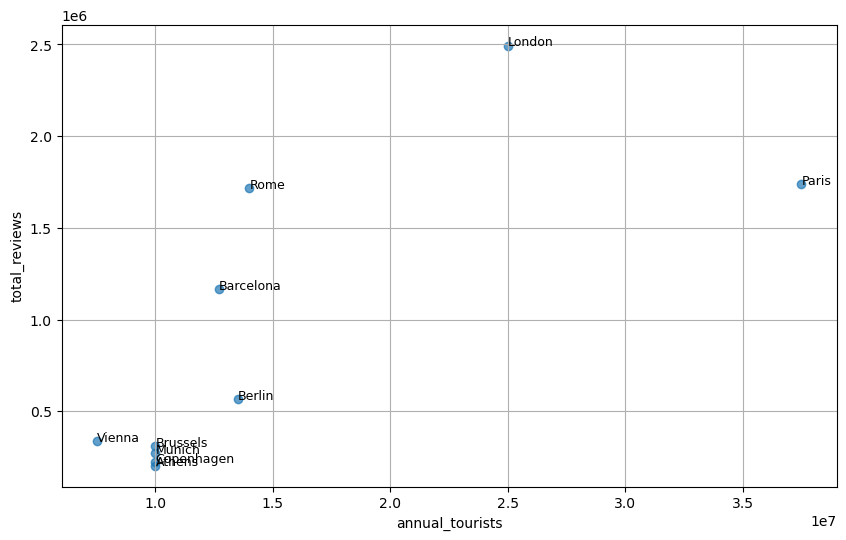

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(destinations_df["annual_tourists"], destinations_df["total_reviews"], alpha=0.7)

for i, row in destinations_df.iterrows():
    plt.text(row["annual_tourists"], row["total_reviews"], row["city"], fontsize=9)

plt.xlabel("annual_tourists")
plt.ylabel("total_reviews")
plt.grid(True)
plt.show()

SCATTER PLOT #1 - WITH TRENDLINE

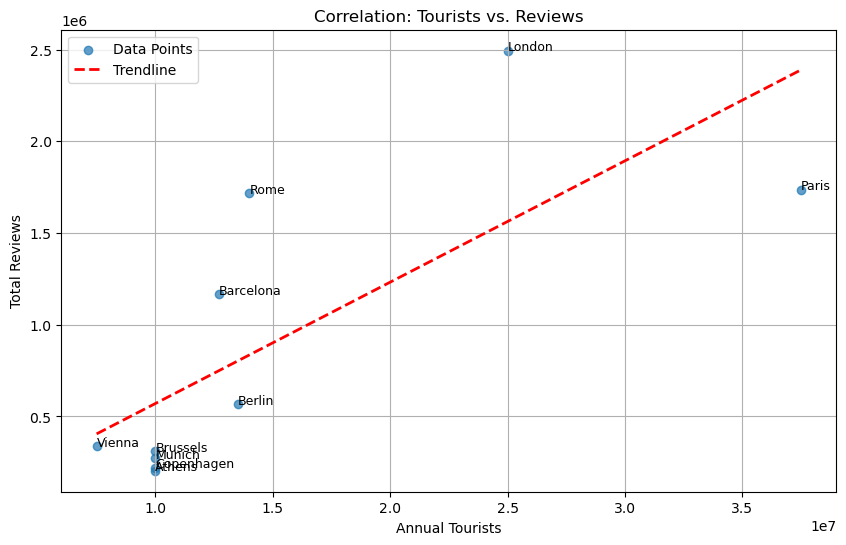

In [10]:

plt.figure(figsize=(10,6))

# 1. Plot the original scatter points
plt.scatter(destinations_df["annual_tourists"], destinations_df["total_reviews"], alpha=0.7, label='Data Points')

# 2. CALCULATE TRENDLINE
# 'z' contains the slope and intercept; 'p' creates the function for the line
z = np.polyfit(destinations_df["annual_tourists"], destinations_df["total_reviews"], 1)
p = np.poly1d(z)

# 3. PLOT TRENDLINE
# We sort the x-values to ensure the line draws correctly from left to right
x_range = np.linspace(destinations_df["annual_tourists"].min(), destinations_df["annual_tourists"].max(), 100)
plt.plot(x_range, p(x_range), color="red", linestyle="--", linewidth=2, label="Trendline")

# 4. Add the labels (Your existing loop)
for i, row in destinations_df.iterrows():
    plt.text(row["annual_tourists"], row["total_reviews"], row["city"], fontsize=9)

plt.xlabel("Annual Tourists")
plt.ylabel("Total Reviews")
plt.title("Correlation: Tourists vs. Reviews")
plt.legend() # Shows which line is the trendline
plt.grid(True)
plt.show()

CALCULATION OF CORRELATION COEFFICIENT

In [11]:
correlation = destinations_df["annual_tourists"].corr(destinations_df["total_reviews"])
print(f"The Correlation Coefficient (r) is: {correlation:.2f}")

The Correlation Coefficient (r) is: 0.74


CALCULATION OF CORRELATION COEFFICIENT (EXCLUDING:PARIS)

In [12]:
# Create a new version of your data without Paris
no_paris_df = destinations_df[destinations_df["city"] != "Paris"]

# Recalculate the correlation
new_corr = no_paris_df["annual_tourists"].corr(no_paris_df["total_reviews"])

print(f"Original Correlation: 0.74")
print(f"Correlation without Paris: {new_corr:.2f}")

Original Correlation: 0.74
Correlation without Paris: 0.90


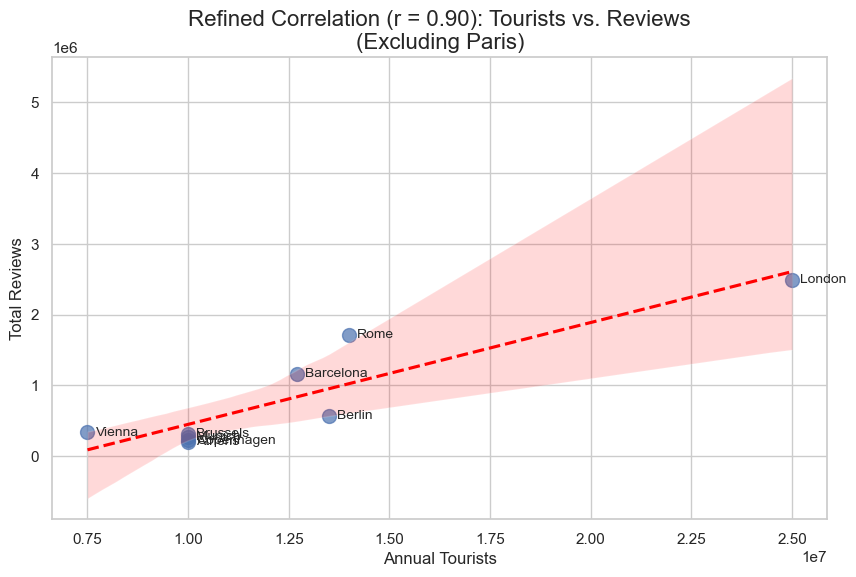

In [13]:

# 1. Create the filtered DataFrame
no_paris_df = destinations_df[destinations_df["city"] != "Paris"]

# 2. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 3. Create the scatterplot with the trendline
# regplot automatically calculates the best-fit line
sns.regplot(
    data=no_paris_df, 
    x="annual_tourists", 
    y="total_reviews", 
    scatter_kws={'s': 100, 'alpha': 0.7}, 
    line_kws={'color': 'red', 'linestyle': '--'}
)

# 4. Add city labels for the remaining points
for i, row in no_paris_df.iterrows():
    plt.text(
        row["annual_tourists"] + 200000, # Offset slightly to the right
        row["total_reviews"], 
        row["city"], 
        fontsize=10,
        verticalalignment='center'
    )

# 5. Labeling and Titles
plt.title(f'Refined Correlation (r = 0.90): Tourists vs. Reviews\n(Excluding Paris)', fontsize=16)
plt.xlabel('Annual Tourists', fontsize=12)
plt.ylabel('Total Reviews', fontsize=12)

plt.show()

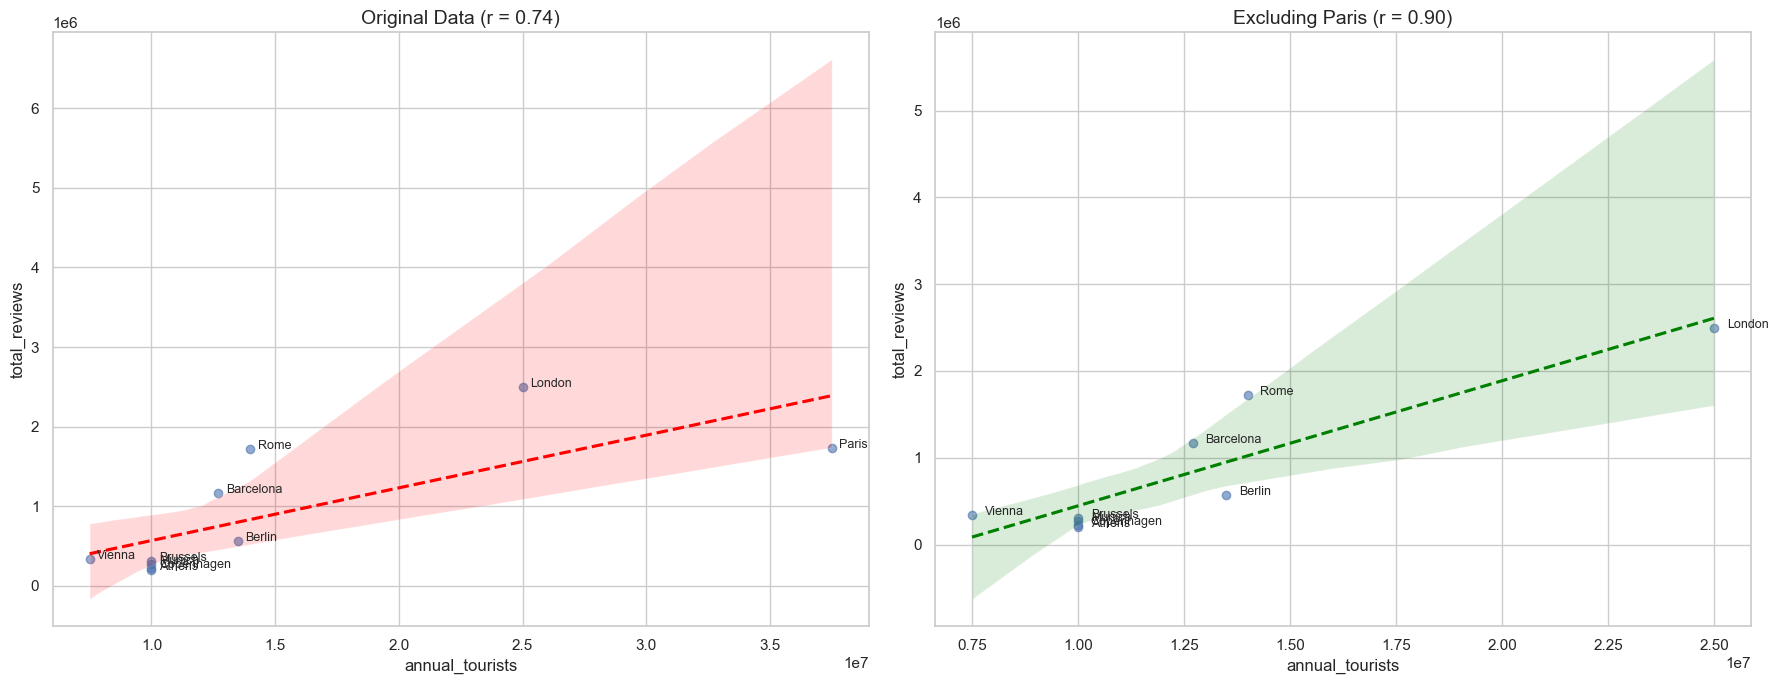

In [14]:

# 1. Create the filtered data
no_paris_df = destinations_df[destinations_df["city"] != "Paris"]

# 2. Set up a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")

# --- LEFT PLOT: WITH PARIS ---
sns.regplot(data=destinations_df, x="annual_tourists", y="total_reviews", 
            ax=ax1, scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'ls':'--'})
ax1.set_title("Original Data (r = 0.74)", fontsize=14)

# --- RIGHT PLOT: WITHOUT PARIS ---
sns.regplot(data=no_paris_df, x="annual_tourists", y="total_reviews", 
            ax=ax2, scatter_kws={'alpha':0.6}, line_kws={'color':'green', 'ls':'--'})
ax2.set_title("Excluding Paris (r = 0.90)", fontsize=14)

# 3. Add city labels to both (Optional, but looks professional)
for df, ax in [(destinations_df, ax1), (no_paris_df, ax2)]:
    for i, row in df.iterrows():
        ax.text(row["annual_tourists"] + 300000, row["total_reviews"], row["city"], fontsize=9)

plt.tight_layout()
plt.show()

CORRELATION EXCLUDING BOTH PARIS AND LONDON 

In [54]:
# 2. Calculate Correlation Coefficients (r)
# Scenario A: All 20 cities
r_full = destinations_all_df['annual_tourists'].corr(destinations_all_df['total_reviews'])

# Scenario B: Excluding Paris only
r_no_paris_2 = destinations_all_df[destinations_all_df['city'] != 'Paris']['annual_tourists'].corr(destinations_all_df[destinations_all_df['city'] != 'Paris']['total_reviews'])

# Scenario C: Excluding BOTH Paris and London
df_filtered = destinations_all_df[~destinations_all_df['city'].isin(['Paris', 'London'])]
r_no_both = df_filtered['annual_tourists'].corr(df_filtered['total_reviews'])

print(f"Correlation (Full): {r_full:.2f}")
print(f"Correlation (No Paris): {r_no_paris_2:.2f}")
print(f"Correlation (No Paris & London): {r_no_both:.2f}")

Correlation (Full): 0.76
Correlation (No Paris): 0.79
Correlation (No Paris & London): 0.56


VISUALIZATION SCATTER PLOT EXCL. PARIS +LONDON 

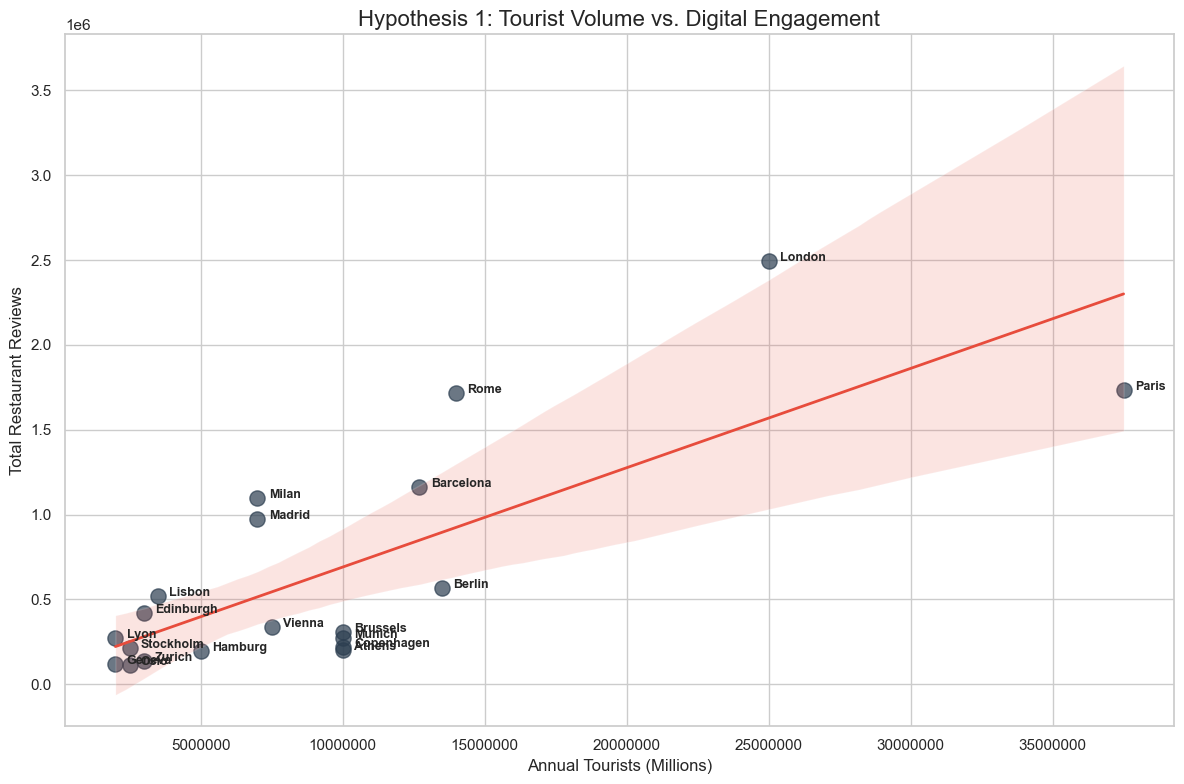

In [56]:

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Create Scatter Plot with Regression Line
ax = sns.regplot(
    data=destinations_all_df, 
    x='annual_tourists', 
    y='total_reviews', 
    scatter_kws={'s': 120, 'alpha': 0.7, 'color': '#2c3e50'}, 
    line_kws={'color': '#e74c3c', 'lw': 2}
)

# 2. Add City Labels (with a tiny offset so they don't sit ON the dots)
for i in range(destinations_all_df.shape[0]):
    plt.text(
        destinations_all_df.annual_tourists.iloc[i] + 400000, 
        destinations_all_df.total_reviews.iloc[i], 
        destinations_all_df.city.iloc[i], 
        fontsize=9, weight='bold'
    )

# 3. Titles and Labels
plt.title('Hypothesis 1: Tourist Volume vs. Digital Engagement', fontsize=16)
plt.xlabel('Annual Tourists (Millions)', fontsize=12)
plt.ylabel('Total Restaurant Reviews', fontsize=12)

# Format the X-axis numbers to be easier to read (not scientific notation)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

OVERVIEW FOR DATASET WITH ALL COUNTRIES, NOT LIMITED TO TOP 10 BY ANNUAL REVIEW

In [15]:
destinations_all_df = pd.read_csv("Hypothesis_1_Table2_No_limit.csv")

In [19]:
destinations_all_df.head(20)

,city,annual_tourists,total_reviews
0,Paris,37500000,1736703
1,London,25000000,2493971
2,Rome,14000000,1717477
3,Berlin,13500000,566687
4,Barcelona,12700000,1165673
5,Athens,10000000,203810
6,Brussels,10000000,310534
7,Copenhagen,10000000,220887
8,Munich,10000000,272273
9,Vienna,7500000,336453


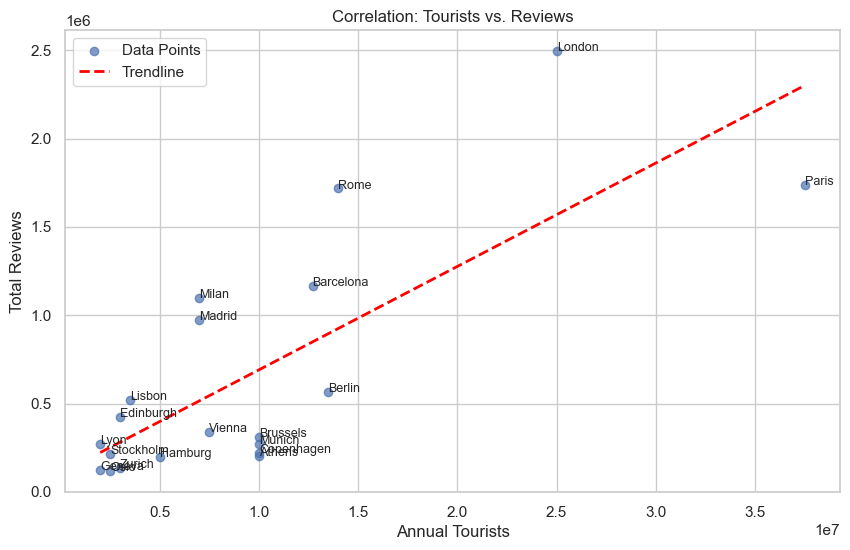

In [20]:
plt.figure(figsize=(10,6))

# 1. Plot the original scatter points
plt.scatter(destinations_all_df["annual_tourists"], destinations_all_df["total_reviews"], alpha=0.7, label='Data Points')

# 2. CALCULATE TRENDLINE
# 'z' contains the slope and intercept; 'p' creates the function for the line
z = np.polyfit(destinations_all_df["annual_tourists"], destinations_all_df["total_reviews"], 1)
p = np.poly1d(z)

# 3. PLOT TRENDLINE
# We sort the x-values to ensure the line draws correctly from left to right
x_range = np.linspace(destinations_all_df["annual_tourists"].min(), destinations_all_df["annual_tourists"].max(), 100)
plt.plot(x_range, p(x_range), color="red", linestyle="--", linewidth=2, label="Trendline")

# 4. Add the labels (Your existing loop)
for i, row in destinations_all_df.iterrows():
    plt.text(row["annual_tourists"], row["total_reviews"], row["city"], fontsize=9)

plt.xlabel("Annual Tourists")
plt.ylabel("Total Reviews")
plt.title("Correlation: Tourists vs. Reviews")
plt.legend() # Shows which line is the trendline
plt.grid(True)
plt.show()

CORRELATION VALUE CALCULATION BETWEEN NUMBER OF TOURISTS AND REVIEWS LEFT

In [21]:
correlation = destinations_all_df["annual_tourists"].corr(destinations_all_df["total_reviews"])
print(f"The Correlation Coefficient (r) is: {correlation:.2f}")

The Correlation Coefficient (r) is: 0.76


COMPARE CORRELATION VALUES (WITHOUT OUTLIER, in this case Paris)

In [24]:
# Create a new version of your data without Paris
no_paris_2_df = destinations_all_df[destinations_all_df["city"] != "Paris"]

# Recalculate the correlation
new_2_corr = no_paris_2_df["annual_tourists"].corr(no_paris_2_df["total_reviews"])

print(f"Original Correlation: 0.76")
print(f"Correlation without Paris: {new_2_corr:.2f}")

Original Correlation: 0.76
Correlation without Paris: 0.79


TOP 5 CITIES (IN TERMS OF ANNUAL TOURISTS) - RESTAURANTS VS. REVIEWS

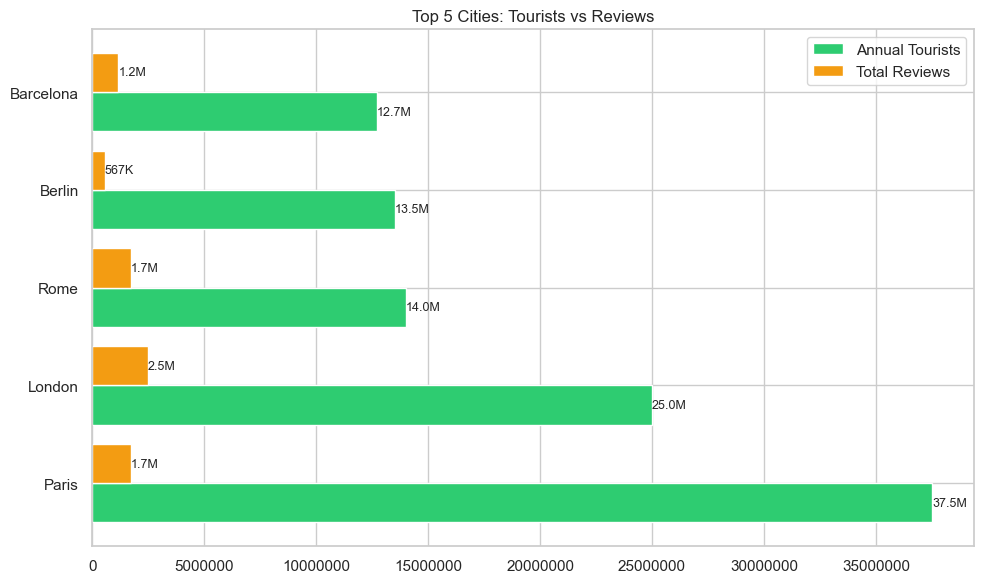

In [57]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

top5 = destinations_df.sort_values("annual_tourists", ascending=False).head(5)

def format_millions(x):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.0f}K"
    return str(int(x))

y = np.arange(len(top5))
height = 0.4

plt.figure(figsize=(10,6))

bars1 = plt.barh(
    y - height/2,
    top5["annual_tourists"],
    height,
    label="Annual Tourists",
    color="#2ecc71"
)

bars2 = plt.barh(
    y + height/2,
    top5["total_reviews"],
    height,
    label="Total Reviews",
    color="#f39c12"
)

# Remove scientific notation (the "1e7" / "le7" issue)
plt.ticklabel_format(style='plain', axis='x')

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,
            bar.get_y() + bar.get_height()/2,
            format_millions(width),
            va='center',
            fontsize=9
        )

plt.yticks(y, top5["city"])
plt.title("Top 5 Cities: Tourists vs Reviews")
plt.legend()
plt.tight_layout()

plt.show()

HYPOTHESIS 2: Cities with a higher cost of living generally have restaurants with higher price levels.

In [25]:
price_level_df = pd.read_csv("Hypothesis_2_Table1_.csv")

In [34]:
price_level_df.head(50)

,city,cost_of_living,avg_price_range
0,Athens,Medium-high,2.1
7,Lyon,Medium-high,2.3
12,Vienna,Medium-high,2.3
11,Stockholm,Medium-high,2.3
1,Barcelona,Medium-high,2.2
9,Munich,Medium-high,2.3
8,Madrid,Medium-high,2.2
10,Rome,Medium-high,2.1
6,Lisbon,Medium-high,2.1
5,Hamburg,Medium-high,2.2


STANDARD BAR CHART - AVERAGE RESTAURANT PRICE LEVEL PER CITY

/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_2976/3459198986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


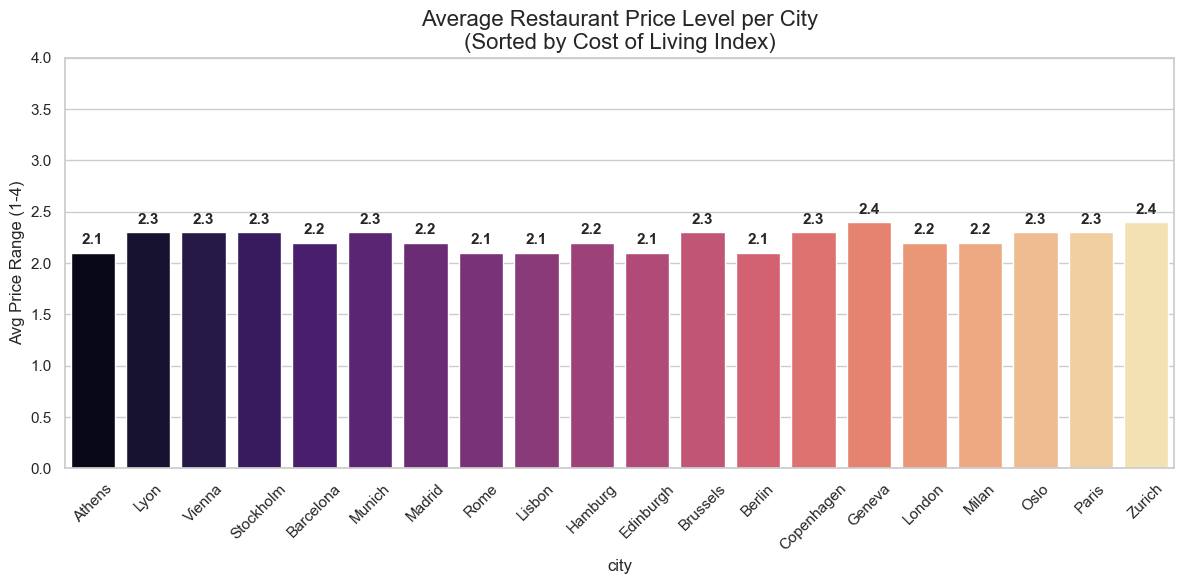

In [63]:

price_level_df_sorted = price_level_df.sort_values(by='cost_of_living', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=price_level_df, 
    x='city', 
    y='avg_price_range', 
    palette='magma'
)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11, 
                fontweight='bold')

plt.title('Average Restaurant Price Level per City\n(Sorted by Cost of Living Index)', fontsize=16)
plt.ylabel('Avg Price Range (1-4)')
plt.xticks(rotation=45)
plt.ylim(0, 4) # Sets a cleaner scale since 4 is max

plt.tight_layout()
plt.show()

TOP 5 CITIES: TOURISTS VS REVIEWS

THE PRICE DISTRIBUTION BOX PLOT -RESTAURANT PRICE VS COST OF LIVING

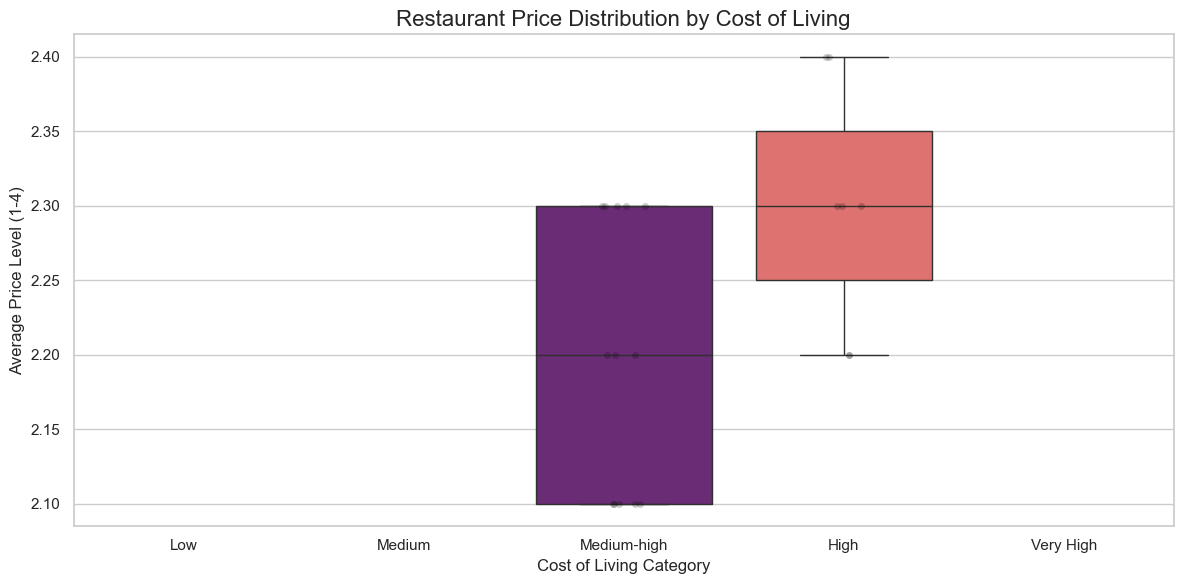

In [48]:
# 1. Define the order so the x-axis isn't alphabetical
# Make sure these strings match your data exactly (e.g. 'Medium-high')
col_order = ['Low', 'Medium', 'Medium-high', 'High', 'Very High']

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. The Fixed Boxplot call
sns.boxplot(
    data=price_level_df, 
    x='cost_of_living', 
    y='avg_price_range', 
    order=col_order,
    hue='cost_of_living', # <--- THIS FIXES THE 'boxprops' ERROR
    palette='magma',
    legend=False          # Hide legend since the x-axis labels are enough
)
sns.stripplot(
    data=price_level_df, 
    x='cost_of_living', 
    y='avg_price_range', 
    order=col_order, 
    color='black',       # Black dots make them stand out
    alpha=0.2,           # Semi-transparent so you can see where they density is high
    size=5)

plt.title('Restaurant Price Distribution by Cost of Living', fontsize=16)
plt.xlabel('Cost of Living Category', fontsize=12)
plt.ylabel('Average Price Level (1-4)', fontsize=12)

plt.tight_layout()
plt.show()

THE PRICE DISTRIBUTION BOX PLOT -RESTAURANT PRICE VS COST OF LIVING (GREEN/ORANGE)

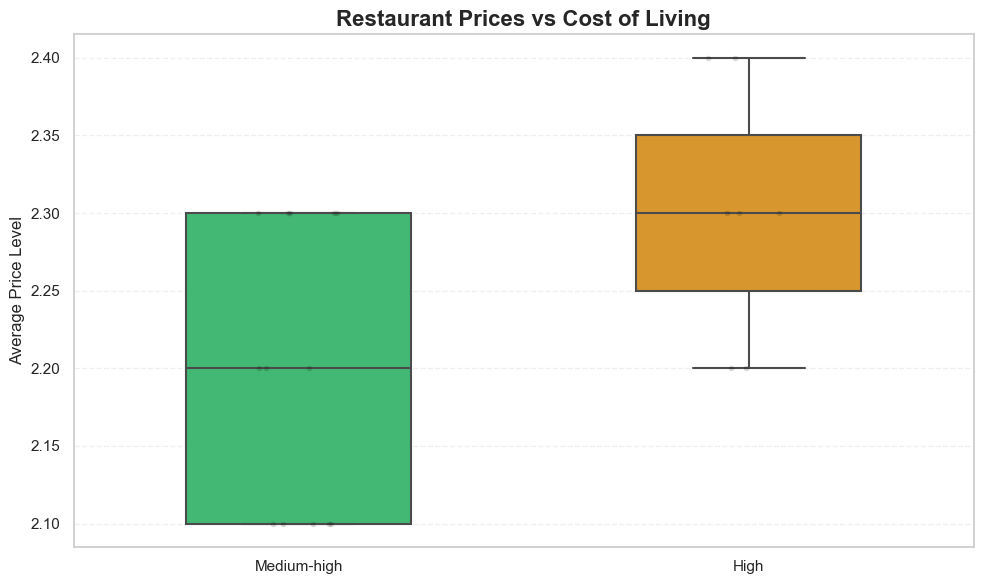

In [59]:

# Filter data
filtered_df = price_level_df[
    price_level_df["cost_of_living"].isin(["Medium-high", "High"])
]

col_order = ["Medium-high", "High"]

# Modern style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# 🎨 Modern green & orange palette
palette = {
    "Medium-high": "#2ecc71",  # 🟢 green
    "High": "#f39c12"          # 🟠 orange
}

# Boxplot
ax = sns.boxplot(
    data=filtered_df,
    x='cost_of_living',
    y='avg_price_range',
    order=col_order,
    hue='cost_of_living',
    palette=palette,
    width=0.5,
    linewidth=1.5,
    fliersize=0  # remove outliers for cleaner look
)

# Overlay points (light + modern)
sns.stripplot(
    data=filtered_df,
    x='cost_of_living',
    y='avg_price_range',
    order=col_order,
    color='black',
    alpha=0.15,
    size=4,
    jitter=True
)


# ✨ Improve titles
plt.title("Restaurant Prices vs Cost of Living", fontsize=16, weight='bold')
plt.xlabel("")
plt.ylabel("Average Price Level", fontsize=12)

# ✨ Subtle grid
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

ANOVA CHECK (CHECK FOR STATISTICAL SIGNIFICANCE OF VALUES)

In [49]:
from scipy import stats

# 1. Group the price data by Cost of Living category
groups = [price_level_df[price_level_df['cost_of_living'] == level]['avg_price_range'] 
          for level in price_level_df['cost_of_living'].unique()]

# 2. Perform the One-Way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value:.4f}")

F-Statistic: 5.85
P-Value: 0.0264


TOP 10 PRICE RANGE CITIES IN GREEN COLOR

/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_2976/28709151.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


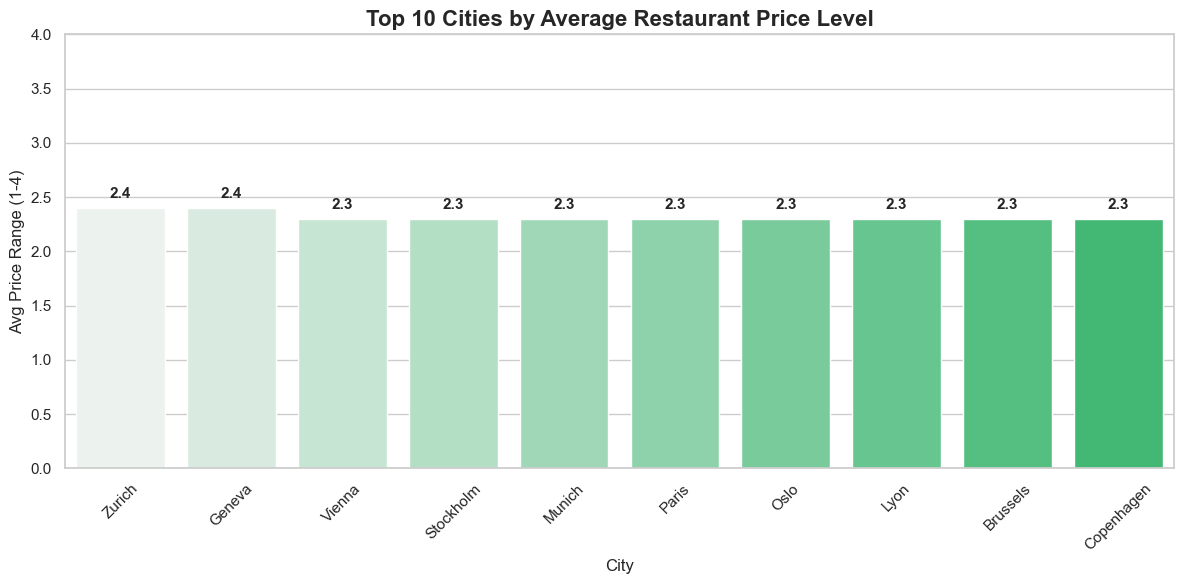

In [ ]:

# 1. Keep only relevant columns + top 10 cities
top10 = price_level_df.sort_values(
    by='avg_price_range',
    ascending=False
).head(10)

# 2. Sort for display (descending cost/price logic if needed)
top10 = top10.sort_values(by='avg_price_range', ascending=False)

# 3. Create green gradient palette
palette = sns.light_palette("#2ecc71", n_colors=len(top10), reverse=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 4. Barplot
ax = sns.barplot(
    data=top10,
    x='city',
    y='avg_price_range',
    palette=palette
)

# 5. Add values on top
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.1f'),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

# 6. Styling (presentation-ready)
plt.title('Top 10 Cities by Average Restaurant Price Level', fontsize=16, weight='bold')
plt.ylabel('Avg Price Range (1-4)')
plt.xlabel('City')

plt.xticks(rotation=45)
plt.ylim(0, 4)

plt.tight_layout()
plt.show()

Top 7cities in terms of average price range:


In [60]:

top7 = price_level_df.sort_values("avg_price_range", ascending=False).head(7)
top7

,city,cost_of_living,avg_price_range
19,Zurich,High,2.4
14,Geneva,High,2.4
12,Vienna,Medium-high,2.3
11,Stockholm,Medium-high,2.3
9,Munich,Medium-high,2.3
18,Paris,High,2.3
17,Oslo,High,2.3


/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_2976/3003542109.py:58: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kl/0dt766hd3b37x_5szjj7k7yw0000gn/T/ipykernel_2976/3003542109.py:58: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


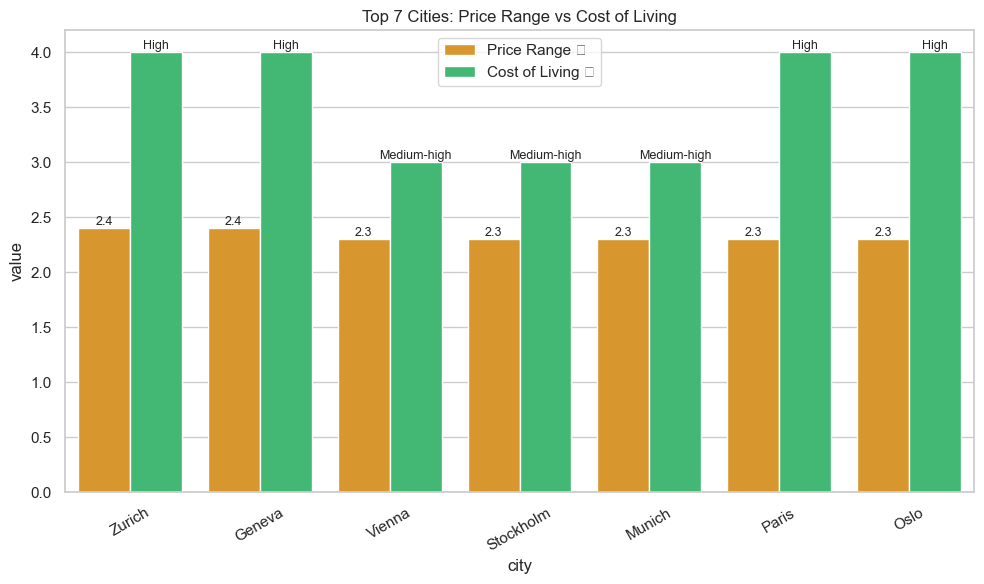

In [61]:
# Top 7
top7 = price_level_df.sort_values("avg_price_range", ascending=False).head(7)

# Convert ONLY for plotting
cost_map = {"Low": 1, "Medium": 2, "Medium-high": 3, "High": 4}
top7["cost_num"] = top7["cost_of_living"].map(cost_map)

# Melt
plot_df = top7.melt(
    id_vars=["city", "cost_of_living"],
    value_vars=["avg_price_range", "cost_num"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=plot_df,
    x="city",
    y="value",
    hue="metric",
    palette={
        "avg_price_range": "#f39c12",  # 🟠
        "cost_num": "#2ecc71"          # 🟢
    }
)

# Custom labels (THIS is the key part)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    
    if pd.isna(height) or height == 0:
        continue

    # If it's cost_of_living → show text instead of number
    if i >= len(top7):  
        city_index = i - len(top7)
        label = top7.iloc[city_index]["cost_of_living"]
    else:
        label = f"{height:.1f}"

    ax.text(
        p.get_x() + p.get_width()/2,
        height,
        label,
        ha="center",
        va="bottom",
        fontsize=9
    )

# Legend
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Price Range 🟠", "Cost of Living 🟢"])

plt.title("Top 7 Cities: Price Range vs Cost of Living")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()